# Estimación de peso de pollos

## Colegio de Posgraduados

### COA661 Inteligencia Artificial

Profesor: Dr. Juan Manuel González Camacho

Entrega: José Alfredo Martínez

Este notebook muestra el preprocesamiento que se hace en el dataset para obtener:

<ol>
    <li>Área (pix^2).</li>
    <li>perímetro (pix).</li>
    <li>Solidez (adimensional).</li>
    <li>Redondez (adimensional).</li>
    <li>Área de polígono convexo (pix^2)</li>
    <li>Eje mayor de elipse (pix)</li>
    <li>Eje menor de elipse (pix)</li>
    <li>Excentricidad (adimensional)</li>
</ol>

In [1]:
# Librerías
%load_ext autoreload
%autoreload 2
    
import numpy as np
import math
import matplotlib.pyplot as plt

from plantcv import plantcv as pcv
import os
import pandas as pd

from Funciones import Preprocesamiento

## Código

In [2]:
# Configuración
localPath = './Fotogramas'

archivos = os.listdir(localPath)
print('Fotografias encontradas: ', len(archivos))

datos = {
    "nombre": [],
    "area": [],
    "perimetro": [],
    "solidez": [],
    "redondez": [],
    "areaPol": [],
    "ejeMayor": [],
    "ejeMenor": [],
    "excentr": [],
    "peso": []
}

Fotografias encontradas:  3118


In [3]:
# Ciclo principal
for archivo in archivos:
    imagen, dirc, file = pcv.readimage(localPath + '/' + archivo)
    imagen2, etiquetas, n = Preprocesamiento(imagen, 5)

    if n == 1:
        # Entrar solo si hay un objeto
        analysis_image = pcv.analyze.size(img = imagen2, labeled_mask = etiquetas, n_labels = n)

        area = pcv.outputs.observations['default_1']['area']['value']
        perimetro = pcv.outputs.observations['default_1']['perimeter']['value']
        
        solidez = pcv.outputs.observations['default_1']['solidity']['value']
        redondez = (perimetro ** 2) / (4 * math.pi * area)

        areaPol = pcv.outputs.observations['default_1']['convex_hull_area']['value']
        ejeMayor = pcv.outputs.observations['default_1']['ellipse_major_axis']['value']
        ejeMenor = pcv.outputs.observations['default_1']['ellipse_minor_axis']['value']
        excentricidad = pcv.outputs.observations['default_1']['ellipse_eccentricity']['value']

        s = file.split('k')

        if len(s) > 1:
            peso = s[0]

            datos["nombre"].append(file)
            datos["area"].append(area)
            datos["perimetro"].append(perimetro)
            datos["solidez"].append(solidez)
            datos["redondez"].append(redondez)
            datos["areaPol"].append(areaPol)
            datos["ejeMayor"].append(ejeMayor)
            datos["ejeMenor"].append(ejeMenor)
            datos["excentr"].append(excentricidad)
            datos["peso"].append(peso)
        else:
            print(file, ' No se pudo extraer el dato de peso del nombre')
    
    elif n == 0:
        print(file, '0 objetos identificados en la fotografía')
    else:
        print(file, ' Tiene más de un objeto')       

2.995kg_00008.jpg 0 objetos identificados en la fotografía
2.995kg_00009.jpg 0 objetos identificados en la fotografía
2.995kg_00010.jpg 0 objetos identificados en la fotografía
2.995kg_00011.jpg 0 objetos identificados en la fotografía
2.995kg_00012.jpg 0 objetos identificados en la fotografía
2.995kg_00013.jpg 0 objetos identificados en la fotografía
2.995kg_00014.jpg 0 objetos identificados en la fotografía
2.995kg_00015.jpg 0 objetos identificados en la fotografía
2.995kg_00036.jpg 0 objetos identificados en la fotografía
2.995kg_00037.jpg 0 objetos identificados en la fotografía
2.995kg_00038.jpg 0 objetos identificados en la fotografía
2.995kg_00039.jpg 0 objetos identificados en la fotografía
2.995kg_00044.jpg 0 objetos identificados en la fotografía
2.995kg_00045.jpg 0 objetos identificados en la fotografía
2.995kg_00046.jpg 0 objetos identificados en la fotografía
2.995kg_00047.jpg 0 objetos identificados en la fotografía
2.995kg_00048.jpg 0 objetos identificados en la fotograf

datos:  3049


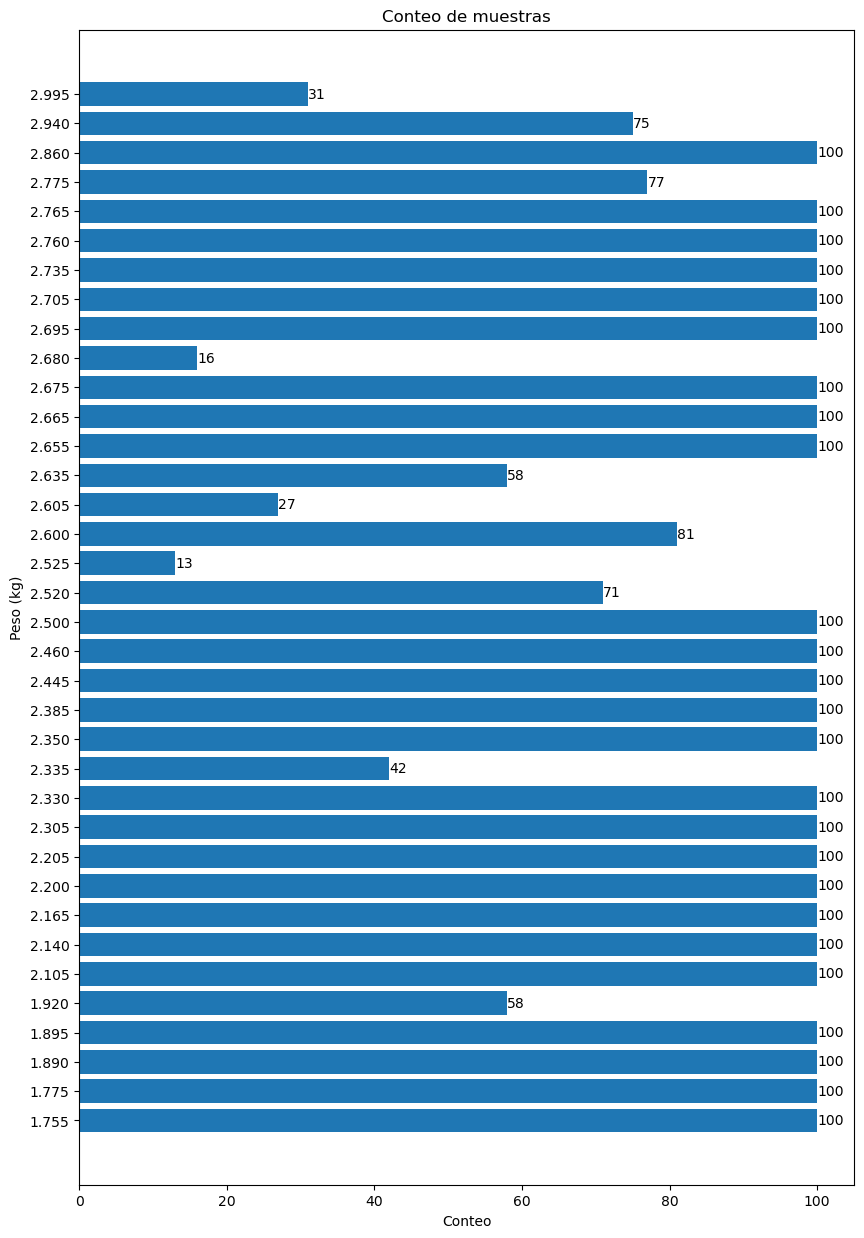

In [4]:
# Contabilizar datos por peso:
valores = np.array(datos['peso'])
unicos, frecuencias = np.unique(valores, return_counts = True)
print('datos: ', np.sum(frecuencias))


fig, ax = plt.subplots(figsize = (10,15))
etiquetas = ax.barh(unicos, frecuencias)
ax.bar_label(etiquetas)
ax.set(ylabel = 'Peso (kg)', xlabel = 'Conteo', title = 'Conteo de muestras')
plt.show()

In [5]:
# Guardar en excel
datos2 = pd.DataFrame(datos)
print(datos2) 
datos2.to_excel('./datosPesoPollo.xlsx', index = False)

                 nombre    area   perimetro   solidez  redondez  areaPol  \
0     1.755kg_00001.jpg  3618.0  305.279218  0.893885  2.049822   4047.5   
1     1.755kg_00002.jpg  3608.0  303.865005  0.886160  2.036503   4071.5   
2     1.755kg_00003.jpg  3584.0  303.279218  0.884174  2.042243   4053.5   
3     1.755kg_00004.jpg  3594.0  300.936073  0.889604  2.005213   4040.0   
4     1.755kg_00005.jpg  3605.0  298.208151  0.892548  1.963016   4039.0   
...                 ...     ...         ...       ...       ...      ...   
3044  2.995kg_00035.jpg  6185.0  400.190906  0.862321  2.060558   7172.5   
3045  2.995kg_00040.jpg  6407.0  381.663994  0.891347  1.809247   7188.0   
3046  2.995kg_00041.jpg  6407.0  381.663994  0.891347  1.809247   7188.0   
3047  2.995kg_00042.jpg  6411.0  380.835567  0.891903  1.800277   7188.0   
3048  2.995kg_00043.jpg  6408.0  381.663994  0.891486  1.808964   7188.0   

        ejeMayor   ejeMenor   excentr   peso  
0      96.193687  52.079929  0.840761  1